#   Minha Primeira Rede Neural em PyTorch: MNIST do Zero

## Imports

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt



## Configs

In [3]:
batch_size = 64
learning_rate = 0.001
epochs = 10
seed = 42

torch.manual_seed(seed)

## DEVICE

In [4]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"  # Mac com Apple Silicon
else:
    device = "cpu"

print("Device:", device)

Device: mps


## Dataset


In [5]:
transform = transforms.ToTensor()

dataset_completo = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataset_teste = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [6]:
imagem, label = dataset_completo[0]


print("\n================ UMA AMOSTRA ================")

print("Tipo da imagem:")
print(type(imagem))

print("\nShape:")
print(imagem.shape)

print("\nTipo dos dados:")
print(imagem.dtype)

print("\nLabel:")
print(label)

print("\nPixel mínimo:")
print(imagem.min().item())

print("\nPixel máximo:")
print(imagem.max().item())

print("\nPixel médio:")
print(imagem.mean().item())


================ UMA AMOSTRA ================
Tipo da imagem:
<class 'torch.Tensor'>

Shape:
torch.Size([1, 28, 28])

Tipo dos dados:
torch.float32

Label:
5

Pixel mínimo:
0.0

Pixel máximo:
1.0

Pixel médio:
0.1376800686120987


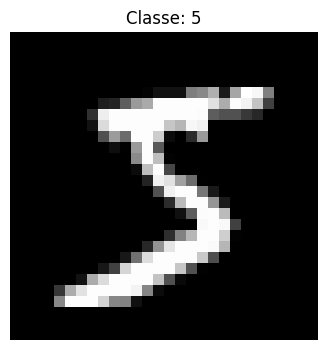

In [7]:
plt.figure(figsize=(4, 4))

plt.imshow(
    imagem.squeeze(),
    cmap="gray"
)

plt.title(f"Classe: {label}")

plt.axis("off")

plt.show()

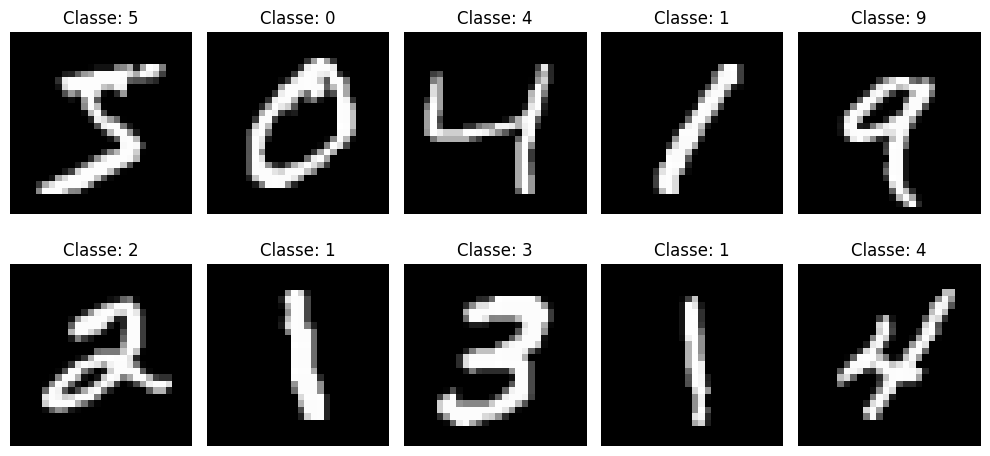

In [8]:
# ============================================================
# 5. VISUALIZANDO EXEMPLOS DO MNIST
# ============================================================

plt.figure(figsize=(10, 5))

for i in range(10):

    imagem, label = dataset_completo[i]

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        imagem.squeeze(),
        cmap="gray"
    )

    plt.title(f"Classe: {label}")

    plt.axis("off")


plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# 6. DISTRIBUIÇÃO DAS CLASSES
# ============================================================

# Os labels originais do MNIST ficam em .targets

labels_treino = dataset_completo.targets


# Conta quantas vezes aparece cada classe

contagem_classes = torch.bincount(labels_treino)


print("\n================ CLASSES ================")

for classe, quantidade in enumerate(contagem_classes):

    print(
        f"Classe {classe}: "
        f"{quantidade.item()} exemplos"
    )


================ CLASSES ================
Classe 0: 5923 exemplos
Classe 1: 6742 exemplos
Classe 2: 5958 exemplos
Classe 3: 6131 exemplos
Classe 4: 5842 exemplos
Classe 5: 5421 exemplos
Classe 6: 5918 exemplos
Classe 7: 6265 exemplos
Classe 8: 5851 exemplos
Classe 9: 5949 exemplos


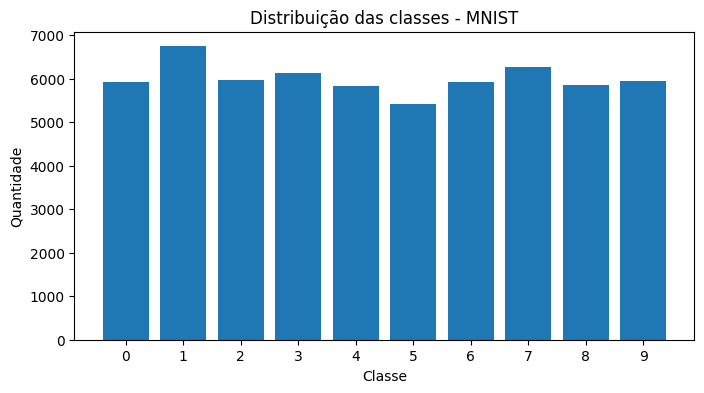

In [10]:
plt.figure(figsize=(8, 4))

plt.bar(
    range(10),
    contagem_classes.numpy()
)

plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.title("Distribuição das classes - MNIST")

plt.xticks(range(10))

plt.show()

## Divisão treino / validação


In [11]:
tamanho_treino = 50_000
tamanho_validacao = 10_000

dataset_treino, dataset_validacao = random_split(
    dataset_completo,
    [tamanho_treino, tamanho_validacao],
    generator=torch.Generator().manual_seed(seed)
)
print("Treino:", len(dataset_treino))
print("Validação:", len(dataset_validacao))
print("Teste:", len(dataset_teste))

Treino: 50000
Validação: 10000
Teste: 10000


## DataLoaders


In [12]:
loader_treino = DataLoader(
    dataset_treino,
    batch_size=batch_size,
    shuffle=True
)

loader_validacao = DataLoader(
    dataset_validacao,
    batch_size=batch_size,
    shuffle=False
)

loader_teste = DataLoader(
    dataset_teste,
    batch_size=batch_size,
    shuffle=False
)

# ============================================================
# 9. ENTENDENDO UM BATCH
# ============================================================

X_batch, y_batch = next(iter(loader_treino))


print("\n================ BATCH ================")

print("Shape de X:")
print(X_batch.shape)

print("\nShape de y:")
print(y_batch.shape)

print("\nPrimeiros labels:")
print(y_batch[:])


================ BATCH ================
Shape de X:
torch.Size([64, 1, 28, 28])

Shape de y:
torch.Size([64])

Primeiros labels:
tensor([9, 2, 6, 8, 0, 5, 9, 2, 2, 0, 7, 4, 1, 2, 9, 9, 1, 4, 1, 2, 5, 9, 3, 7,
        4, 5, 3, 9, 9, 6, 2, 0, 7, 6, 9, 9, 0, 5, 2, 3, 0, 2, 8, 0, 7, 7, 6, 3,
        2, 8, 5, 5, 6, 5, 8, 5, 2, 1, 5, 3, 1, 4, 2, 6])


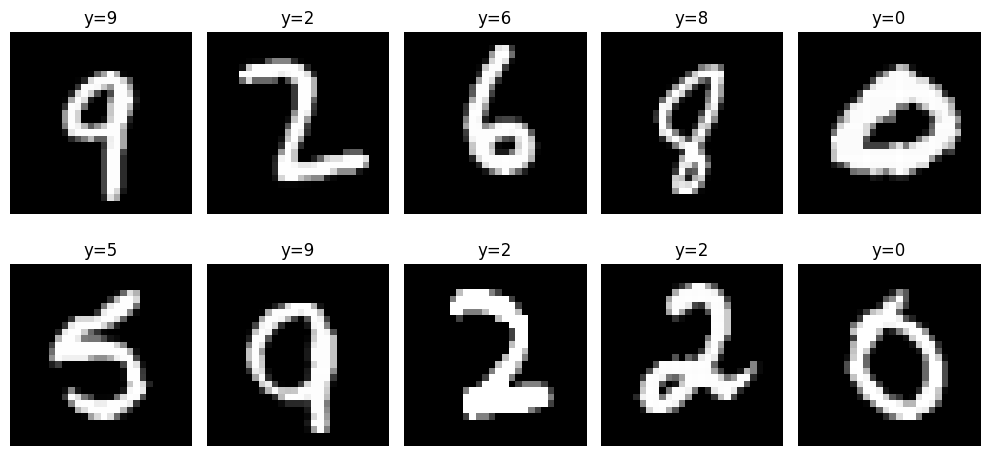

In [13]:
plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_batch[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"y={y_batch[i].item()}"
    )

    plt.axis("off")


plt.tight_layout()
plt.show()

## MLP

In [14]:
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.rede = nn.Sequential(

            # 784 -> 128
            nn.Linear(28 * 28, 128),
            nn.ReLU(),

            # 128 -> 64
            nn.Linear(128, 64),
            nn.ReLU(),

            # 64 -> 10 classes
            nn.Linear(64, 10)
        )

    def forward(self, x):

        # [batch, 1, 28, 28]
        x = self.flatten(x)

        # [batch, 784]
        logits = self.rede(x)

        # [batch, 10]
        return logits


modelo = MLP().to(device)

print(modelo)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (rede): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [15]:
# ============================================================
# 11. PARÂMETROS DO MODELO
# ============================================================

print("\n================ PARÂMETROS ================")


total_parametros = 0


for nome, parametro in modelo.named_parameters():

    quantidade = parametro.numel()

    total_parametros += quantidade


    print(
        f"{nome:20} "
        f"shape={str(list(parametro.shape)):18} "
        f"params={quantidade}"
    )


print("\nTotal de parâmetros treináveis:")
print(f"{total_parametros:,}")


================ PARÂMETROS ================
rede.0.weight        shape=[128, 784]         params=100352
rede.0.bias          shape=[128]              params=128
rede.2.weight        shape=[64, 128]          params=8192
rede.2.bias          shape=[64]               params=64
rede.4.weight        shape=[10, 64]           params=640
rede.4.bias          shape=[10]               params=10

Total de parâmetros treináveis:
109,386


In [16]:
primeira_camada = modelo.rede[0]


print("\n================ PESOS INICIAIS ================")

print("Shape W1:")
print(primeira_camada.weight.shape)

print("\nPrimeiros pesos:")
print(
    primeira_camada.weight[0, :10]
)

print("\nMédia dos pesos:")
print(
    primeira_camada.weight.mean().item()
)

print("\nDesvio padrão:")
print(
    primeira_camada.weight.std().item()
)


================ PESOS INICIAIS ================
Shape W1:
torch.Size([128, 784])

Primeiros pesos:
tensor([-0.0078,  0.0072, -0.0174,  0.0210,  0.0315, -0.0262,  0.0310,  0.0067,
         0.0264,  0.0048], device='mps:0', grad_fn=<SliceBackward0>)

Média dos pesos:
7.09368905518204e-05

Desvio padrão:
0.020636923611164093


In [17]:
# ============================================================
# 12. FORWARD ANTES DO TREINAMENTO
# ============================================================

modelo.eval()


imagem, label_real = dataset_teste[0]


# Adicionamos dimensão do batch:
#
# [1, 28, 28]
#
# vira:
#
# [1, 1, 28, 28]

imagem_batch = imagem.unsqueeze(0).to(device)


with torch.no_grad():

    logits = modelo(imagem_batch)

    probabilidades = torch.softmax(
        logits,
        dim=1
    )


print("\n================ FORWARD INICIAL ================")

print("Classe real:")
print(label_real)

print("\nLogits:")
print(
    logits.cpu()
)

print("\nProbabilidades:")
print(
    probabilidades.cpu()
)

print("\nSoma das probabilidades:")
print(
    probabilidades.sum().item()
)

print("\nClasse prevista:")
print(
    probabilidades.argmax(dim=1).item()
)


================ FORWARD INICIAL ================
Classe real:
7

Logits:
tensor([[ 0.0576,  0.0378,  0.0018, -0.0461, -0.1003,  0.0462,  0.0506,  0.1028,
          0.1197,  0.0077]])

Probabilidades:
tensor([[0.1028, 0.1008, 0.0972, 0.0927, 0.0878, 0.1017, 0.1021, 0.1076, 0.1094,
         0.0978]])

Soma das probabilidades:
1.0

Classe prevista:
8


## Loss e optimizer

In [18]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    modelo.parameters(),
    lr=learning_rate
)

print("\nLoss function:")
print(loss_fn)

print("\nOptimizer:")
print(optimizer)


Loss function:
CrossEntropyLoss()

Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [19]:
# ============================================================
# 14. INSPECIONANDO UM BACKPROP
# ============================================================

# Criamos um NOVO modelo apenas para demonstração
#
# Assim não alteramos o modelo principal.

modelo_debug = MLP().to(device)


optimizer_debug = torch.optim.Adam(
    modelo_debug.parameters(),
    lr=learning_rate
)


X_debug, y_debug = next(iter(loader_treino))

X_debug = X_debug.to(device)
y_debug = y_debug.to(device)


# ------------------------------------------------------------
# FORWARD
# ------------------------------------------------------------

logits_debug = modelo_debug(X_debug)


loss_debug = loss_fn(
    logits_debug,
    y_debug
)


print("\n================ BACKPROP DEBUG ================")

print("Loss antes do backward:")
print(loss_debug.item())


================ BACKPROP DEBUG ================
Loss antes do backward:
2.3161122798919678


In [20]:
print("\nGradiente ANTES de loss.backward():")

print(
    modelo_debug.rede[0].weight.grad
)


Gradiente ANTES de loss.backward():
None


In [21]:
optimizer_debug.zero_grad()


loss_debug.backward()

In [22]:
gradiente = modelo_debug.rede[0].weight.grad


print("\nShape do gradiente de W1:")
print(
    gradiente.shape
)


print("\nPrimeiros gradientes:")
print(
    gradiente[0, :10]
)


print("\nMédia do gradiente:")
print(
    gradiente.mean().item()
)


print("\nNorma do gradiente:")
print(
    gradiente.norm().item()
)


Shape do gradiente de W1:
torch.Size([128, 784])

Primeiros gradientes:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='mps:0')

Média do gradiente:
4.566891220747493e-05

Norma do gradiente:
0.2471296489238739


In [23]:
# Guarda uma cópia dos pesos ANTES do optimizer

peso_antes = (
    modelo_debug.rede[0]
    .weight
    .detach()
    .clone()
)


# Adam atualiza os parâmetros

optimizer_debug.step()


peso_depois = (
    modelo_debug.rede[0]
    .weight
    .detach()
    .clone()
)


print("\nPrimeiros pesos ANTES:")
print(
    peso_antes[0, :5].cpu()
)


print("\nPrimeiros pesos DEPOIS:")
print(
    peso_depois[0, :5].cpu()
)


diferenca = (
    peso_depois
    -
    peso_antes
)


print("\nMudança nos pesos:")
print(
    diferenca[0, :5].cpu()
)


Primeiros pesos ANTES:
tensor([-0.0160,  0.0230, -0.0020, -0.0246, -0.0113])

Primeiros pesos DEPOIS:
tensor([-0.0160,  0.0230, -0.0020, -0.0246, -0.0113])

Mudança nos pesos:
tensor([0., 0., 0., 0., 0.])


## Função de treino


In [24]:
def treinar(loader, modelo, loss_fn, optimizer):

    modelo.train()

    loss_total = 0
    corretos = 0
    total = 0

    for X, y in loader:

        X = X.to(device)
        y = y.to(device)

        # --------------------------------
        # FORWARD
        # --------------------------------

        logits = modelo(X)

        # --------------------------------
        # LOSS
        # --------------------------------

        loss = loss_fn(logits, y)

        # --------------------------------
        # BACKPROPAGATION
        # --------------------------------

        optimizer.zero_grad()

        loss.backward()

        # --------------------------------
        # GRADIENT DESCENT / OPTIMIZER
        # --------------------------------

        optimizer.step()

        # --------------------------------
        # Métricas
        # --------------------------------

        loss_total += loss.item() * X.size(0)

        predicoes = logits.argmax(dim=1)

        corretos += (predicoes == y).sum().item()
        total += y.size(0)

    loss_media = loss_total / total
    acuracia = corretos / total

    return loss_media, acuracia

## Validação

In [25]:
def avaliar(loader, modelo, loss_fn):

    modelo.eval()

    loss_total = 0
    corretos = 0
    total = 0

    # Não precisamos de gradientes durante avaliação
    with torch.no_grad():

        for X, y in loader:

            X = X.to(device)
            y = y.to(device)

            logits = modelo(X)

            loss = loss_fn(logits, y)

            loss_total += loss.item() * X.size(0)

            predicoes = logits.argmax(dim=1)

            corretos += (predicoes == y).sum().item()
            total += y.size(0)

    loss_media = loss_total / total
    acuracia = corretos / total

    return loss_media, acuracia

## Loop de Treinamento

In [26]:
historico = {

    "train_loss": [],

    "val_loss": [],

    "train_acc": [],

    "val_acc": []
}

In [28]:
# ============================================================
# 18. TREINAMENTO
# ============================================================

print("\n================ TREINAMENTO ================\n")


for epoch in range(epochs):

    loss_treino, acc_treino = treinar(
        loader_treino,
        modelo,
        loss_fn,
        optimizer
    )


    loss_val, acc_val = avaliar(
        loader_validacao,
        modelo,
        loss_fn
    )


    # Guardando histórico

    historico["train_loss"].append(
        loss_treino
    )

    historico["val_loss"].append(
        loss_val
    )

    historico["train_acc"].append(
        acc_treino
    )

    historico["val_acc"].append(
        acc_val
    )


    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"Train Loss: {loss_treino:.4f} | "
        f"Train Acc: {acc_treino:.2%} | "
        f"Val Loss: {loss_val:.4f} | "
        f"Val Acc: {acc_val:.2%}"
    )
    


================ TREINAMENTO ================

Epoch 01/10 | Train Loss: 0.3657 | Train Acc: 89.87% | Val Loss: 0.2076 | Val Acc: 93.84%
Epoch 02/10 | Train Loss: 0.1542 | Train Acc: 95.51% | Val Loss: 0.1459 | Val Acc: 95.64%
Epoch 03/10 | Train Loss: 0.1061 | Train Acc: 96.80% | Val Loss: 0.1289 | Val Acc: 95.96%
Epoch 04/10 | Train Loss: 0.0799 | Train Acc: 97.64% | Val Loss: 0.1120 | Val Acc: 96.54%
Epoch 05/10 | Train Loss: 0.0622 | Train Acc: 98.08% | Val Loss: 0.0923 | Val Acc: 97.15%
Epoch 06/10 | Train Loss: 0.0505 | Train Acc: 98.43% | Val Loss: 0.0969 | Val Acc: 97.14%
Epoch 07/10 | Train Loss: 0.0389 | Train Acc: 98.74% | Val Loss: 0.1036 | Val Acc: 97.04%
Epoch 08/10 | Train Loss: 0.0326 | Train Acc: 99.01% | Val Loss: 0.1025 | Val Acc: 97.19%
Epoch 09/10 | Train Loss: 0.0272 | Train Acc: 99.10% | Val Loss: 0.0931 | Val Acc: 97.39%
Epoch 10/10 | Train Loss: 0.0212 | Train Acc: 99.31% | Val Loss: 0.1062 | Val Acc: 97.40%


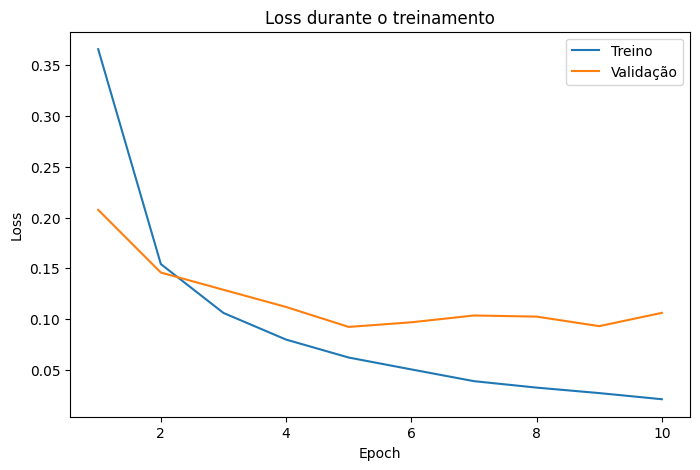

In [29]:
# ============================================================
# 19. CURVA DA LOSS
# ============================================================

plt.figure(figsize=(8, 5))


plt.plot(
    range(1, epochs + 1),
    historico["train_loss"],
    label="Treino"
)


plt.plot(
    range(1, epochs + 1),
    historico["val_loss"],
    label="Validação"
)


plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss durante o treinamento")

plt.legend()

plt.show()

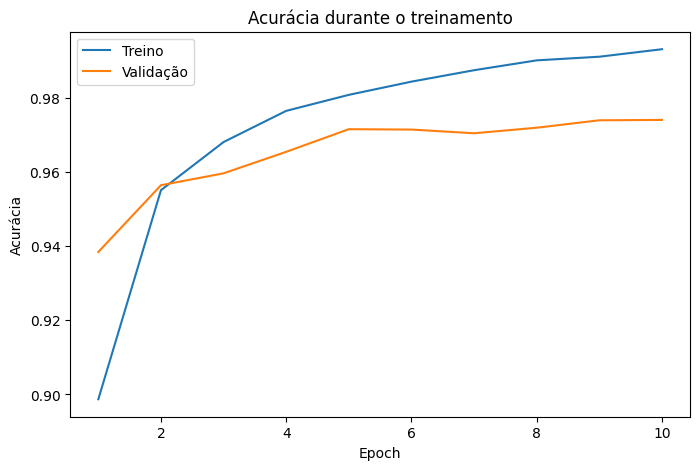

In [30]:
# ============================================================
# 20. CURVA DA ACURÁCIA
# ============================================================

plt.figure(figsize=(8, 5))


plt.plot(
    range(1, epochs + 1),
    historico["train_acc"],
    label="Treino"
)


plt.plot(
    range(1, epochs + 1),
    historico["val_acc"],
    label="Validação"
)


plt.xlabel("Epoch")
plt.ylabel("Acurácia")

plt.title("Acurácia durante o treinamento")

plt.legend()

plt.show()

## Avaliação final no teste


In [12]:
loss_teste, acc_teste = avaliar(
    loader_teste,
    modelo,
    loss_fn
)

print("\nResultado final:")
print(f"Test Loss: {loss_teste:.4f}")
print(f"Test Accuracy: {acc_teste:.4f}")


Resultado final:
Test Loss: 0.0972
Test Accuracy: 0.9750


In [31]:
# ============================================================
# 22. PREVISÃO INDIVIDUAL
# ============================================================

modelo.eval()


imagem, label_real = dataset_teste[0]


imagem_batch = (
    imagem
    .unsqueeze(0)
    .to(device)
)


with torch.no_grad():

    logits = modelo(
        imagem_batch
    )


    probabilidades = torch.softmax(
        logits,
        dim=1
    )


classe_prevista = (
    probabilidades
    .argmax(dim=1)
    .item()
)


print("\n================ PREVISÃO ================")

print("Classe real:")
print(label_real)

print("\nLogits:")
print(logits.cpu())

print("\nProbabilidades:")

for classe, prob in enumerate(
    probabilidades[0].cpu()
):

    print(
        f"{classe}: {prob.item():.2%}"
    )


print("\nClasse prevista:")
print(classe_prevista)


================ PREVISÃO ================
Classe real:
7

Logits:
tensor([[ -7.8160,  -3.8477,   0.2461,   0.9345, -15.0635,  -7.1136, -21.6616,
          11.2805,  -2.4291,  -2.1141]])

Probabilidades:
0: 0.00%
1: 0.00%
2: 0.00%
3: 0.00%
4: 0.00%
5: 0.00%
6: 0.00%
7: 99.99%
8: 0.00%
9: 0.00%

Classe prevista:
7


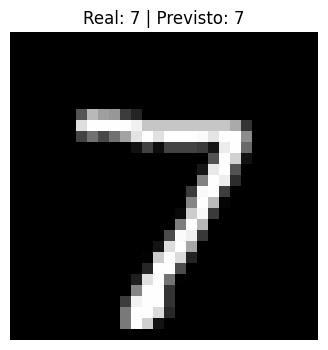

In [32]:
plt.figure(figsize=(4, 4))

plt.imshow(
    imagem.squeeze(),
    cmap="gray"
)

plt.title(
    f"Real: {label_real} | "
    f"Previsto: {classe_prevista}"
)

plt.axis("off")

plt.show()

In [34]:
# ============================================================
# 23. MATRIZ DE CONFUSÃO
# ============================================================

matriz_confusao = torch.zeros(
    10,
    10,
    dtype=torch.int64
)


modelo.eval()


with torch.no_grad():

    for X, y in loader_teste:

        X = X.to(device)

        logits = modelo(X)

        predicoes = logits.argmax(
            dim=1
        )


        # Voltamos para CPU para análise

        predicoes = predicoes.cpu()


        for real, previsto in zip(
            y,
            predicoes
        ):

            matriz_confusao[
                real,
                previsto
            ] += 1

print("\n================ MATRIZ DE CONFUSÃO ================")

print(matriz_confusao)


================ MATRIZ DE CONFUSÃO ================
tensor([[ 965,    0,    1,    0,    0,    3,    6,    1,    4,    0],
        [   0, 1115,    5,    0,    0,    0,    2,    0,   13,    0],
        [   1,    0, 1023,    1,    1,    0,    3,    1,    2,    0],
        [   0,    0,   15,  977,    0,    8,    0,    4,    6,    0],
        [   1,    0,    1,    0,  957,    0,    6,    2,    2,   13],
        [   2,    1,    1,    5,    2,  873,    4,    0,    3,    1],
        [   4,    1,    1,    1,    4,    3,  944,    0,    0,    0],
        [   3,    3,   17,    2,    2,    0,    1,  994,    2,    4],
        [   4,    0,    4,    2,    2,    5,    3,    4,  949,    1],
        [   2,    4,    1,    8,    7,    7,    0,    1,    7,  972]])


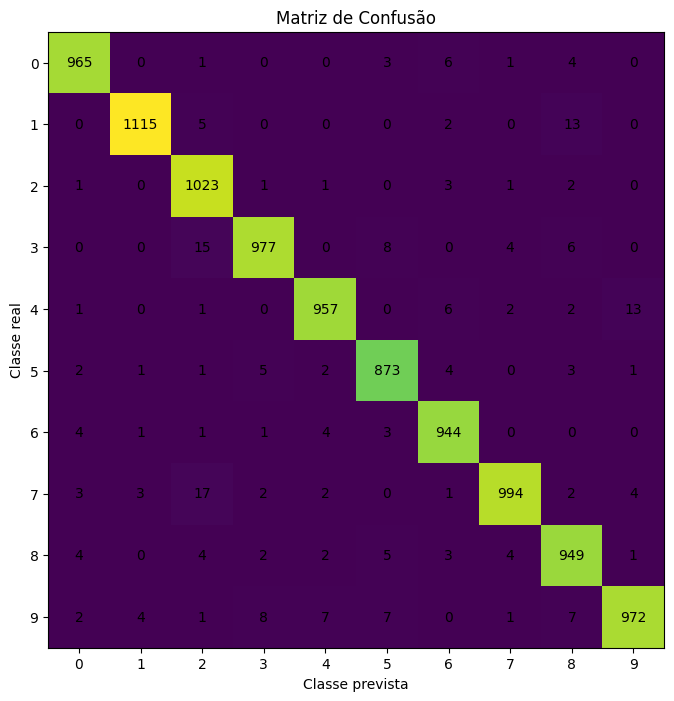

In [35]:
plt.figure(figsize=(8, 8))

plt.imshow(
    matriz_confusao.numpy()
)

plt.xlabel("Classe prevista")
plt.ylabel("Classe real")

plt.title("Matriz de Confusão")

plt.xticks(range(10))
plt.yticks(range(10))


for i in range(10):

    for j in range(10):

        valor = matriz_confusao[i, j].item()

        plt.text(
            j,
            i,
            valor,
            ha="center",
            va="center"
        )


plt.show()

In [36]:
# ============================================================
# 24. EXEMPLOS ERRADOS
# ============================================================

modelo.eval()


erros = []


with torch.no_grad():

    for X, y in loader_teste:

        X_device = X.to(device)


        logits = modelo(
            X_device
        )


        probabilidades = torch.softmax(
            logits,
            dim=1
        )


        predicoes = logits.argmax(
            dim=1
        )


        # Voltamos os resultados para CPU

        probabilidades = (
            probabilidades.cpu()
        )

        predicoes = (
            predicoes.cpu()
        )


        mascara_erros = (
            predicoes != y
        )


        for (
            imagem,
            real,
            previsto,
            probs
        ) in zip(

            X[mascara_erros],

            y[mascara_erros],

            predicoes[mascara_erros],

            probabilidades[mascara_erros]
        ):

            confianca = probs[
                previsto
            ].item()


            erros.append({

                "imagem": imagem,

                "real": real.item(),

                "previsto": previsto.item(),

                "confianca": confianca
            })


print("\n================ ERROS ================")

print(
    "Número de erros:",
    len(erros)
)

print(
    "Número de acertos:",
    len(dataset_teste) - len(erros)
)

print(
    "Taxa de erro:",
    f"{len(erros) / len(dataset_teste):.2%}"
)


================ ERROS ================
Número de erros: 231
Número de acertos: 9769
Taxa de erro: 2.31%


In [37]:
# Ordenamos do erro MAIS CONFIANTE
# para o MENOS CONFIANTE

erros_ordenados = sorted(

    erros,

    key=lambda x: x["confianca"],

    reverse=True
)

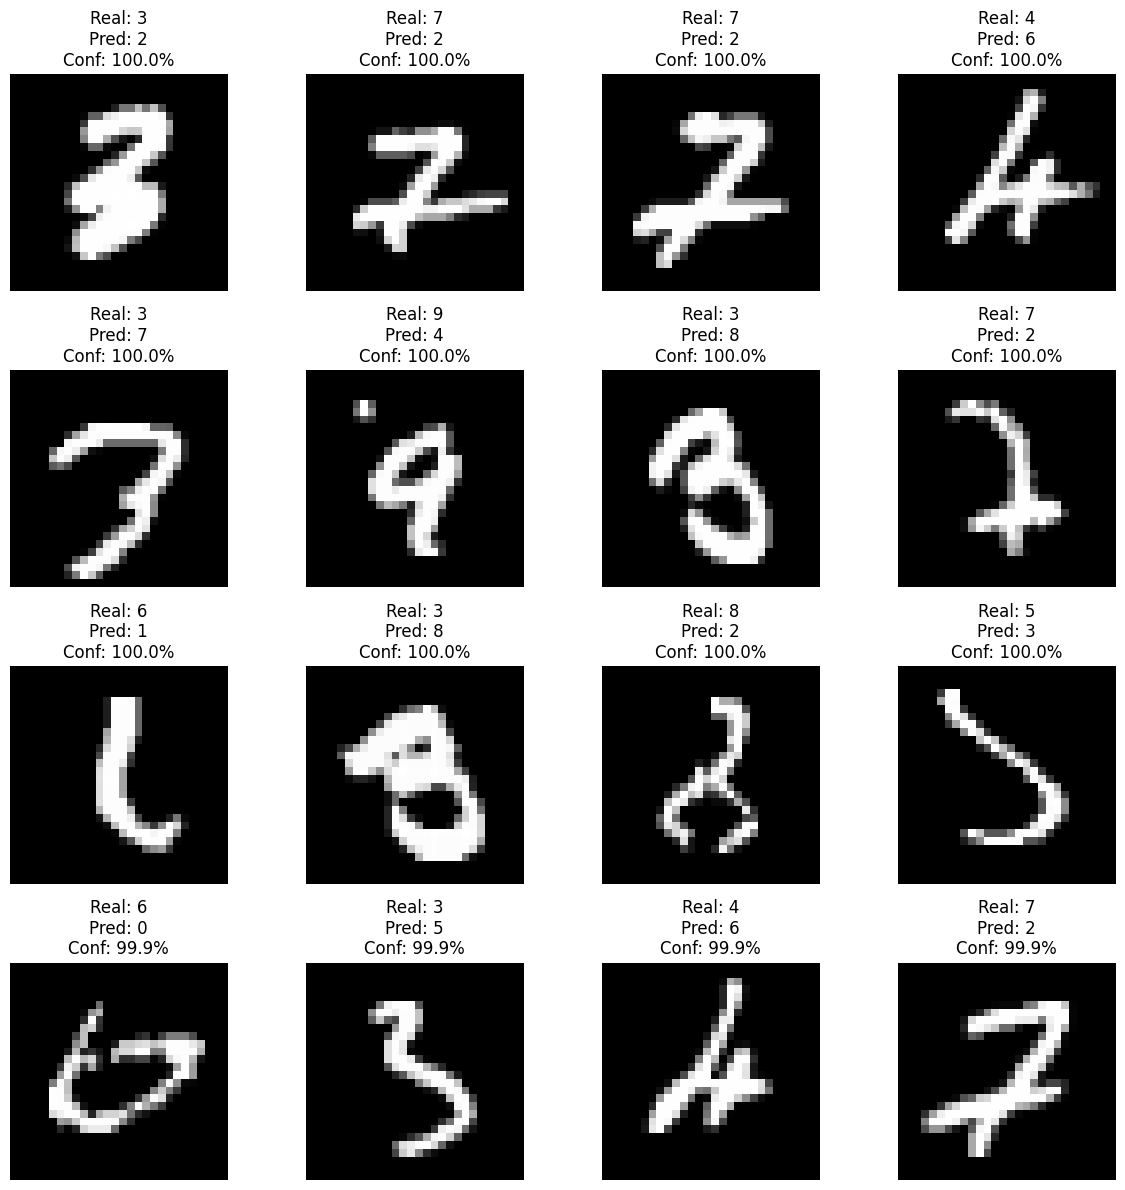

In [38]:
quantidade = 16


plt.figure(figsize=(12, 12))


for i, erro in enumerate(
    erros_ordenados[:quantidade]
):

    plt.subplot(
        4,
        4,
        i + 1
    )


    plt.imshow(
        erro["imagem"].squeeze(),
        cmap="gray"
    )


    plt.title(

        f"Real: {erro['real']}\n"

        f"Pred: {erro['previsto']}\n"

        f"Conf: {erro['confianca']:.1%}"
    )


    plt.axis("off")


plt.tight_layout()

plt.show()